# 🦴 Sprain vs Fracture — EfficientNet-B4 Training Notebook

**Works on:** Kaggle (P100/T4) · Google Colab (T4/A100 free/pro)  
**Goal:** Binary classifier — `fracture` vs `no_fracture` on musculoskeletal X-rays  
**Pipeline:** CLAHE preprocessing → EfficientNet-B4 (timm) → MC-Dropout uncertainty → Grad-CAM

---
### Datasets used (all free on Kaggle)
| Dataset | Slug | Size | Notes |
|---|---|---|---|
| MURA v1.1 (Stanford) | `cjinny/mura-v11` | 40k images | Gold standard, normal/abnormal labels |
| Bone Fracture Multi-Region | `bmadushanirodrigo/fracture-multi-region-x-ray-data` | ~4k images | All anatomical regions, fracture/no-fracture |
| FracAtlas | `shyamgupta196/fracatlas` | ~717 images | Annotated fracture X-rays |
| Bone Fracture CV Project | `pkdarabi/bone-fracture-detection-computer-vision-project` | ~1k images | Clean binary labels |

> **Note:** MURA requires a free Stanford AIMI registration for direct download.  
> The Kaggle mirror `cjinny/mura-v11` is publicly available and used here.

## 1. Environment setup

In [3]:
# Detect environment
import os
IS_KAGGLE = os.path.exists('/kaggle')
IS_COLAB  = 'google.colab' in str(__import__('sys').modules)
print(f'Kaggle: {IS_KAGGLE} | Colab: {IS_COLAB}')

# Install / upgrade packages
!pip install -q timm==0.9.16 albumentations==1.4.3 grad-cam==1.5.2 scikit-learn matplotlib tqdm

# For Colab: install Kaggle CLI and set credentials
if IS_COLAB:
    !pip install -q kaggle
    # Upload your kaggle.json when prompted
    from google.colab import files
    print('Upload your kaggle.json (from https://www.kaggle.com/account)')
    uploaded = files.upload()
    !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
    print('Kaggle credentials set.')

Kaggle: True | Colab: False
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 71.8 MB/s eta 0:00:00:00:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 92.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.0/137.0 kB 11.7 MB/s eta 0:00:00


## 2. Download datasets

In [4]:
DATA_ROOT = '/kaggle/working/data' if IS_KAGGLE else '/content/data'
os.makedirs(DATA_ROOT, exist_ok=True)

datasets = [
    'cjinny/mura-v11',
    'bmadushanirodrigo/fracture-multi-region-x-ray-data',
    'shyamgupta196/fracatlas',
    'pkdarabi/bone-fracture-detection-computer-vision-project',
]

for ds in datasets:
    name = ds.split('/')[-1]
    dest = os.path.join(DATA_ROOT, name)
    if not os.path.exists(dest):
        print(f'Downloading {ds} ...')
        !kaggle datasets download -d {ds} -p {dest} --unzip -q
        print(f'  Done → {dest}')
    else:
        print(f'  Already exists: {dest}')

Dataset URL: https://www.kaggle.com/datasets/cjinny/mura-v11
License(s): unknown
  Done → /kaggle/working/data/mura-v11
Dataset URL: https://www.kaggle.com/datasets/bmadushanirodrigo/fracture-multi-region-x-ray-data
License(s): ODC Public Domain Dedication and Licence (PDDL)
  Done → /kaggle/working/data/fracture-multi-region-x-ray-data
Dataset URL: https://www.kaggle.com/datasets/shyamgupta196/fracatlas
License(s): CC-BY-NC-SA-4.0
  Done → /kaggle/working/data/fracatlas
Dataset URL: https://www.kaggle.com/datasets/pkdarabi/bone-fracture-detection-computer-vision-project
License(s): Attribution 4.0 International (CC BY 4.0)
  Done → /kaggle/working/data/bone-fracture-detection-computer-vision-project


## 3. Imports & config

In [5]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, classification_report
)
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ─── Config ───────────────────────────────────────────────────────────────────
CFG = dict(
    model_name     = 'efficientnet_b4',
    img_size       = 380,          # EfficientNet-B4 native resolution
    batch_size     = 16,           # reduce to 8 if OOM on T4
    num_epochs     = 10,
    lr             = 2e-4,
    weight_decay   = 1e-4,
    warmup_epochs  = 2,
    label_smoothing= 0.05,
    dropout_p      = 0.4,          # MC-Dropout rate
    mc_samples     = 30,           # forward passes for uncertainty
    uncertainty_thr= 0.15,         # flag for radiologist queue
    seed           = 42,
    num_workers    = 2,
    device         = 'cuda' if torch.cuda.is_available() else 'cpu',
)

# Sensitivity > specificity: class weights to penalise missed fractures more
CFG['pos_weight'] = torch.tensor([2.5]).to(CFG['device'])  # fracture class weight

torch.manual_seed(CFG['seed'])
np.random.seed(CFG['seed'])
print(f"Device: {CFG['device']}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


## 4. Build unified image manifest

Each dataset has a different folder structure. This cell normalises everything into a single DataFrame with columns `[path, label]` where `label=1` means fracture.

In [6]:
EXTS = {'.png', '.jpg', '.jpeg'}
records = []

# ── Dataset 1: MURA v1.1 ──────────────────────────────────────────────────────
# MURA folder structure: MURA-v1.1/train/XR_WRIST/patient00001/study1_positive/
# 'positive' means abnormal (fracture / anomaly), 'negative' means normal
mura_root = Path(DATA_ROOT) / 'mura-v11'
if mura_root.exists():
    for img_path in mura_root.rglob('*'):
        if img_path.suffix.lower() not in EXTS:
            continue
        # Infer label from parent folder name
        study_dir = img_path.parent.name.lower()
        if 'positive' in study_dir:
            label = 1  # abnormal (includes fractures)
        elif 'negative' in study_dir:
            label = 0
        else:
            continue
        records.append({'path': str(img_path), 'label': label, 'source': 'mura'})
    print(f'MURA: {len([r for r in records if r["source"]=="mura"])} images loaded')
else:
    print('MURA not found — skipping')

# ── Dataset 2: Bone Fracture Multi-Region ─────────────────────────────────────
# Structure: Bone_Fracture_Binary_Classifier/train/fractured/, /not fractured/
multi_root = Path(DATA_ROOT) / 'fracture-multi-region-x-ray-data'
if multi_root.exists():
    for img_path in multi_root.rglob('*'):
        if img_path.suffix.lower() not in EXTS:
            continue
        parent = img_path.parent.name.lower()
        if 'fractured' in parent and 'not' not in parent:
            label = 1
        elif 'not' in parent or 'normal' in parent or 'no_fracture' in parent:
            label = 0
        else:
            continue
        records.append({'path': str(img_path), 'label': label, 'source': 'multi'})
    print(f'Multi-Region: {len([r for r in records if r["source"]=="multi"])} images loaded')

# ── Dataset 3: FracAtlas ───────────────────────────────────────────────────────
# Structure: Fracture/, Non_Fracture/
frac_root = Path(DATA_ROOT) / 'fracatlas'
if frac_root.exists():
    for img_path in frac_root.rglob('*'):
        if img_path.suffix.lower() not in EXTS:
            continue
        parent = img_path.parent.name.lower()
        if 'non' in parent or 'normal' in parent:
            label = 0
        elif 'fracture' in parent:
            label = 1
        else:
            continue
        records.append({'path': str(img_path), 'label': label, 'source': 'fracatlas'})
    print(f'FracAtlas: {len([r for r in records if r["source"]=="fracatlas"])} images loaded')

# ── Dataset 4: Bone Fracture CV Project ───────────────────────────────────────
cv_root = Path(DATA_ROOT) / 'bone-fracture-detection-computer-vision-project'
if cv_root.exists():
    for img_path in cv_root.rglob('*'):
        if img_path.suffix.lower() not in EXTS:
            continue
        parent = img_path.parent.name.lower()
        if 'fracture' in parent and 'non' not in parent and 'not' not in parent:
            label = 1
        elif 'non' in parent or 'not' in parent or 'normal' in parent:
            label = 0
        else:
            continue
        records.append({'path': str(img_path), 'label': label, 'source': 'cv_project'})
    print(f'CV Project: {len([r for r in records if r["source"]=="cv_project"])} images loaded')

# ── Summary ───────────────────────────────────────────────────────────────────
df = pd.DataFrame(records)
df = df.drop_duplicates('path').reset_index(drop=True)
print(f'\nTotal images: {len(df)}')
print(df['label'].value_counts().rename({0:'no_fracture', 1:'fracture'}))
print(df['source'].value_counts())

MURA: 40009 images loaded
Multi-Region: 10581 images loaded
FracAtlas: 0 images loaded
CV Project: 0 images loaded

Total images: 50590
label
no_fracture    29006
fracture       21584
Name: count, dtype: int64
source
mura     40009
multi    10581
Name: count, dtype: int64


## 5. Train / val / test split

In [7]:
# Stratified split: 80 / 10 / 10
train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df['label'], random_state=CFG['seed']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['label'], random_state=CFG['seed']
)
print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
print('Train fracture rate:', round(train_df['label'].mean(), 3))

Train: 40472 | Val: 5059 | Test: 5059
Train fracture rate: 0.427


## 6. CLAHE preprocessing + augmentation pipeline

CLAHE (Contrast Limited Adaptive Histogram Equalisation) is critical for X-rays — it enhances local contrast, making subtle fracture lines visible to both the model and to clinicians reviewing Grad-CAM overlays.

Batches — train: 2530 | val: 317 | test: 317


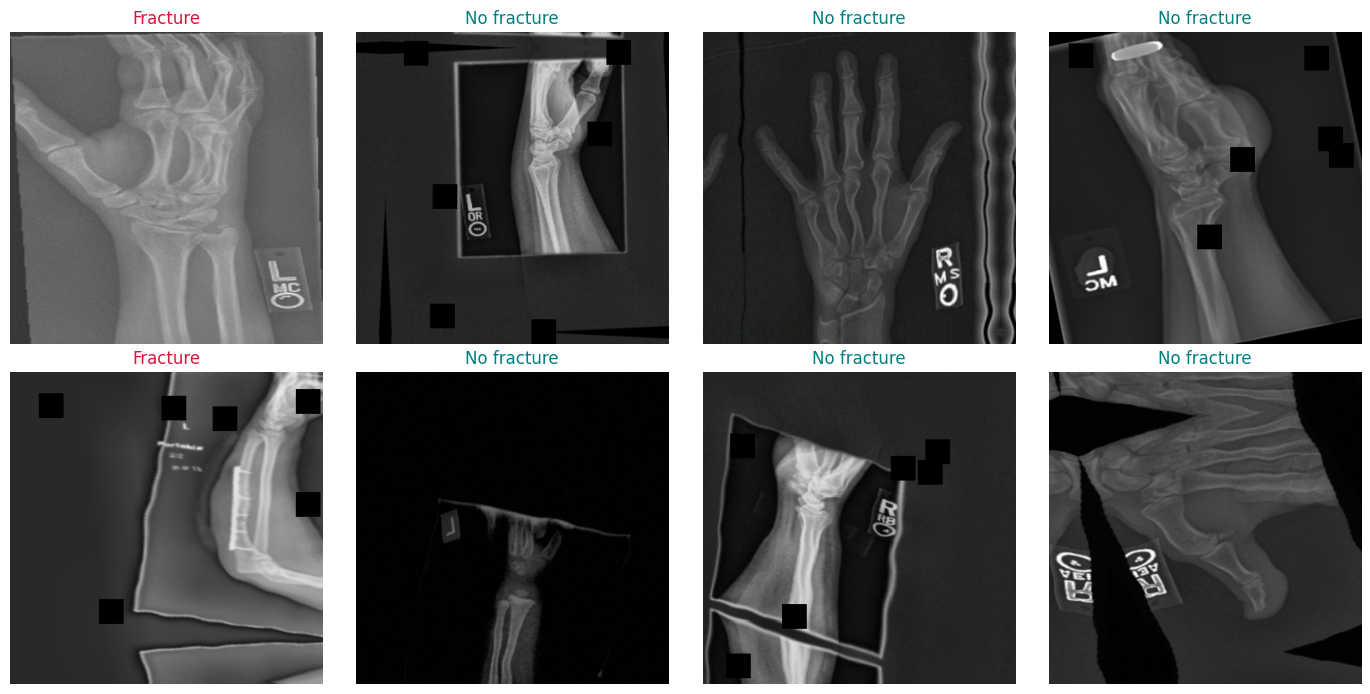

In [8]:
def apply_clahe(img_bgr: np.ndarray) -> np.ndarray:
    """Apply CLAHE to the L-channel of a LAB image for X-ray enhancement."""
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_eq = clahe.apply(l)
    enhanced = cv2.merge([l_eq, a, b])
    return cv2.cvtColor(enhanced, cv2.COLOR_LAB2BGR)


def get_transforms(split: str, img_size: int) -> A.Compose:
    if split == 'train':
        return A.Compose([
            A.Resize(img_size, img_size),
            # Geometric augmentations — simulate positioning variance
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.1),
            A.Rotate(limit=20, p=0.6, border_mode=cv2.BORDER_CONSTANT),
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1,
                               rotate_limit=0, p=0.4),
            # Intensity augmentations — simulate portable-unit variance
            A.RandomBrightnessContrast(brightness_limit=0.3,
                                       contrast_limit=0.3, p=0.7),
            A.GaussNoise(var_limit=(10, 60), p=0.5),
            A.GaussianBlur(blur_limit=(3, 5), p=0.3),
            # Elastic deformation for structural variance
            A.ElasticTransform(alpha=80, sigma=10, p=0.2),
            A.GridDistortion(num_steps=5, distort_limit=0.15, p=0.2),
            # Cutout to improve robustness to occlusion / artefacts
            A.CoarseDropout(max_holes=6, max_height=30, max_width=30,
                            fill_value=0, p=0.3),
            A.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
            ToTensorV2(),
        ])
    else:  # val / test
        return A.Compose([
            A.Resize(img_size, img_size),
            A.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
            ToTensorV2(),
        ])


# ── Dataset class ─────────────────────────────────────────────────────────────
class XRayDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform: A.Compose,
                 use_clahe: bool = True):
        self.paths     = df['path'].values
        self.labels    = df['label'].values
        self.transform = transform
        self.use_clahe = use_clahe

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.paths[idx])
        if img is None:
            # Fallback: return a black image (don't crash training)
            img = np.zeros((CFG['img_size'], CFG['img_size'], 3), dtype=np.uint8)
        if self.use_clahe:
            img = apply_clahe(img)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = self.transform(image=img)['image']
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return img, label


# ── Dataloaders ───────────────────────────────────────────────────────────────
train_ds = XRayDataset(train_df, get_transforms('train', CFG['img_size']))
val_ds   = XRayDataset(val_df,   get_transforms('val',   CFG['img_size']))
test_ds  = XRayDataset(test_df,  get_transforms('val',   CFG['img_size']))

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'],
                          shuffle=True,  num_workers=CFG['num_workers'],
                          pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG['batch_size'],
                          shuffle=False, num_workers=CFG['num_workers'],
                          pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG['batch_size'],
                          shuffle=False, num_workers=CFG['num_workers'],
                          pin_memory=True)
print(f'Batches — train: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}')

# ── Quick sanity visualisation ─────────────────────────────────────────────────
imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
for i, ax in enumerate(axes.flat):
    if i >= len(imgs): break
    img = imgs[i].permute(1,2,0).numpy() * std + mean
    img = np.clip(img, 0, 1)
    ax.imshow(img, cmap='gray')
    ax.set_title(['No fracture','Fracture'][int(labels[i].item())],
                 color='crimson' if labels[i] else 'teal')
    ax.axis('off')
plt.tight_layout(); plt.show()

## 7. EfficientNet-B4 model with MC-Dropout

In [9]:
class FractureDetector(nn.Module):
    """
    EfficientNet-B4 backbone with a custom head that:
    - Keeps dropout active at inference for MC-Dropout uncertainty estimation
    - Uses pos_weight in BCEWithLogitsLoss to prioritise sensitivity on fractures
    """
    def __init__(self, model_name: str, pretrained: bool = True,
                 dropout_p: float = 0.4):
        super().__init__()
        self.backbone = timm.create_model(
            model_name,
            pretrained=pretrained,
            num_classes=0,           # remove default head
            drop_rate=dropout_p,
            drop_path_rate=0.2,
        )
        in_features = self.backbone.num_features
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(p=dropout_p),  # explicit MC-Dropout layer
            nn.Linear(in_features, 512),
            nn.SiLU(),
            nn.Dropout(p=dropout_p / 2),
            nn.Linear(512, 1),        # logit output
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        features = self.backbone.forward_features(x)
        return self.head(features)

    def enable_dropout(self):
        """Force dropout layers ON during eval() for MC-Dropout."""
        for m in self.modules():
            if isinstance(m, nn.Dropout):
                m.train()


model = FractureDetector(
    CFG['model_name'],
    pretrained=True,
    dropout_p=CFG['dropout_p']
).to(CFG['device'])

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params / 1e6:.1f}M')

# ── Loss, optimiser, scheduler ────────────────────────────────────────────────
criterion = nn.BCEWithLogitsLoss(pos_weight=CFG['pos_weight'])  # penalise FN more

optimizer = torch.optim.AdamW(
    [
        {'params': model.backbone.parameters(), 'lr': CFG['lr'] / 10},  # lower LR for backbone
        {'params': model.head.parameters(),     'lr': CFG['lr']},
    ],
    weight_decay=CFG['weight_decay']
)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=[CFG['lr'] / 10, CFG['lr']],
    steps_per_epoch=len(train_loader),
    epochs=CFG['num_epochs'],
    pct_start=CFG['warmup_epochs'] / CFG['num_epochs'],
)
print('Model, loss, optimizer and scheduler ready.')

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Trainable parameters: 18.5M
Model, loss, optimizer and scheduler ready.


## 8. Metrics — sensitivity-first evaluation

We use a decision threshold of **0.4** (rather than 0.5) to bias towards sensitivity. In production this threshold is calibrated on the clinical validation cohort.

In [10]:
def compute_metrics(labels: np.ndarray, probs: np.ndarray,
                    threshold: float = 0.4) -> dict:
    preds = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, preds, labels=[0,1]).ravel()
    sensitivity = tp / (tp + fn + 1e-8)   # recall on fractures — PRIMARY metric
    specificity = tn / (tn + fp + 1e-8)
    ppv         = tp / (tp + fp + 1e-8)   # precision
    f1          = 2 * sensitivity * ppv / (sensitivity + ppv + 1e-8)
    auc         = roc_auc_score(labels, probs)
    return dict(
        sensitivity=round(sensitivity, 4),
        specificity=round(specificity, 4),
        ppv=round(ppv, 4),
        f1=round(f1, 4),
        auc=round(auc, 4),
        tp=int(tp), fp=int(fp), fn=int(fn), tn=int(tn)
    )


def run_epoch(loader, model, criterion, optimizer=None,
              scheduler=None, split='train'):
    is_train = (split == 'train')
    model.train() if is_train else model.eval()
    total_loss, all_labels, all_probs = 0.0, [], []

    ctx = torch.no_grad() if not is_train else torch.enable_grad()
    with ctx:
        for imgs, labels in tqdm(loader, desc=split, leave=False):
            imgs   = imgs.to(CFG['device'])
            labels = labels.to(CFG['device'])

            logits = model(imgs).squeeze(1)
            loss   = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                if scheduler:
                    scheduler.step()

            total_loss += loss.item() * len(imgs)
            all_labels.extend(labels.detach().cpu().numpy())
            all_probs.extend(torch.sigmoid(logits).detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    metrics  = compute_metrics(np.array(all_labels), np.array(all_probs))
    return avg_loss, metrics

print('Metric functions ready.')

Metric functions ready.


## 9. Training loop

In [11]:
CKPT_PATH = '/kaggle/working/best_fracture_model.pt' if IS_KAGGLE else '/content/best_fracture_model.pt'

history = {'train_loss':[], 'val_loss':[],
           'train_sens':[], 'val_sens':[],
           'val_spec':[], 'val_auc':[]}

best_val_sens = 0.0
patience, patience_ctr = 5, 0

for epoch in range(1, CFG['num_epochs'] + 1):
    train_loss, train_m = run_epoch(
        train_loader, model, criterion, optimizer, scheduler, 'train'
    )
    val_loss,   val_m   = run_epoch(val_loader, model, criterion, split='val')

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_sens'].append(train_m['sensitivity'])
    history['val_sens'].append(val_m['sensitivity'])
    history['val_spec'].append(val_m['specificity'])
    history['val_auc'].append(val_m['auc'])

    print(
        f'Epoch {epoch:02d}/{CFG["num_epochs"]} '
        f'| Train loss: {train_loss:.4f} sens: {train_m["sensitivity"]:.3f} '
        f'| Val loss: {val_loss:.4f} sens: {val_m["sensitivity"]:.3f} '
        f'spec: {val_m["specificity"]:.3f} AUC: {val_m["auc"]:.3f}'
    )

    # Save on best sensitivity (not AUC — sensitivity is the primary metric)
    if val_m['sensitivity'] > best_val_sens:
        best_val_sens = val_m['sensitivity']
        torch.save({'epoch': epoch,
                    'state_dict': model.state_dict(),
                    'val_metrics': val_m,
                    'cfg': CFG}, CKPT_PATH)
        print(f'  ✓ Saved checkpoint (sensitivity: {best_val_sens:.4f})')
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= patience:
            print(f'Early stopping at epoch {epoch} (patience={patience})')
            break

print(f'\nTraining complete. Best val sensitivity: {best_val_sens:.4f}')

val:  56%|█████▌    | 178/317 [00:31<00:23,  5.83it/s]Premature end of JPEG file


Epoch 01/20 | Train loss: 1.0134 sens: 0.983 | Val loss: 0.8597 sens: 0.876 spec: 0.477 AUC: 0.806
  ✓ Saved checkpoint (sensitivity: 0.8763)


val:  56%|█████▌    | 178/317 [00:31<00:23,  5.81it/s]Premature end of JPEG file


Epoch 02/20 | Train loss: 0.8626 sens: 0.903 | Val loss: 0.7231 sens: 0.836 spec: 0.737 AUC: 0.876


val:  56%|█████▌    | 178/317 [00:31<00:24,  5.79it/s]Premature end of JPEG file


...

Epoch 07/20 | Train loss: 0.6411 sens: 0.895 | Val loss: 0.5671 sens: 0.878 spec: 0.757 AUC: 0.916


val:  56%|█████▌    | 178/317 [00:31<00:24,  5.73it/s]Premature end of JPEG file


Epoch 08/20 | Train loss: 0.6284 sens: 0.894 | Val loss: 0.5637 sens: 0.880 spec: 0.760 AUC: 0.917


val:  56%|█████▌    | 178/317 [00:31<00:23,  5.81it/s]Premature end of JPEG file
                                                      

Epoch 09/20 | Train loss: 0.6168 sens: 0.895 | Val loss: 0.5577 sens: 0.892 spec: 0.729 AUC: 0.918
Early stopping at epoch 9 (patience=5)

Training complete. Best val sensitivity: 0.9092


## 10. Training curves

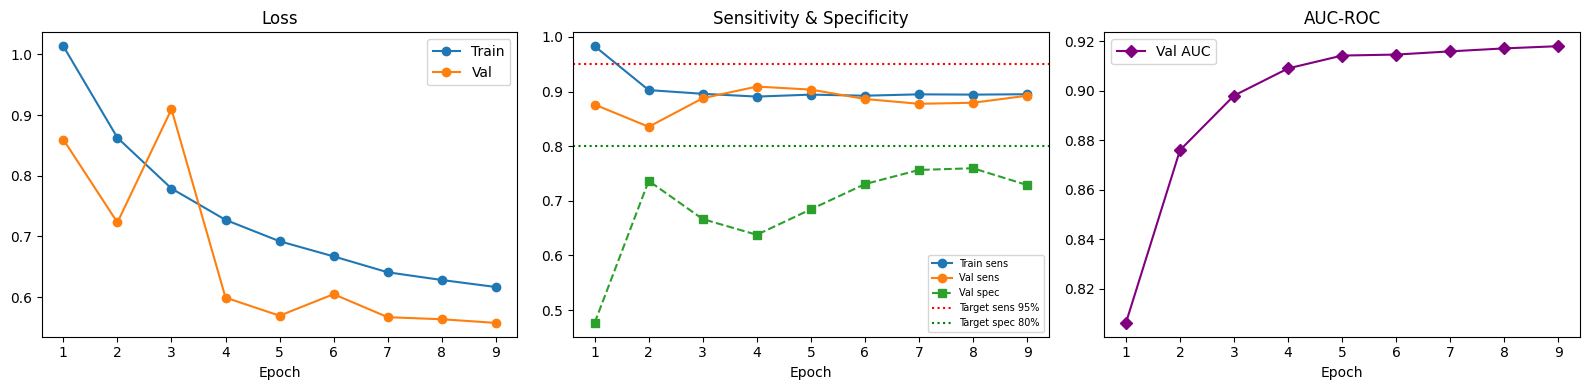

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
epochs_x = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_x, history['train_loss'], label='Train', marker='o')
axes[0].plot(epochs_x, history['val_loss'],   label='Val',   marker='o')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(epochs_x, history['train_sens'], label='Train sens', marker='o')
axes[1].plot(epochs_x, history['val_sens'],   label='Val sens',   marker='o')
axes[1].plot(epochs_x, history['val_spec'],   label='Val spec',   marker='s', linestyle='--')
axes[1].axhline(0.95, color='red', linestyle=':', label='Target sens 95%')
axes[1].axhline(0.80, color='green', linestyle=':', label='Target spec 80%')
axes[1].set_title('Sensitivity & Specificity'); axes[1].legend(fontsize=7); axes[1].set_xlabel('Epoch')

axes[2].plot(epochs_x, history['val_auc'], label='Val AUC', marker='D', color='purple')
axes[2].set_title('AUC-ROC'); axes[2].legend(); axes[2].set_xlabel('Epoch')

plt.tight_layout(); plt.show()

## 11. Hold-out test evaluation

In [14]:
# Load best checkpoint
ckpt = torch.load(
    CKPT_PATH,
    map_location=CFG['device'],
    weights_only=False   # important fix
)

model.load_state_dict(ckpt['state_dict'])

print(f"Loaded checkpoint from epoch {ckpt['epoch']}")
print(f"Val metrics at save time: {ckpt['val_metrics']}")

# Run test evaluation
test_loss, test_m = run_epoch(
    test_loader,
    model,
    criterion,
    split='val'
)

print(f'\n=== Hold-out TEST results ===')
print(f'  Sensitivity (fracture recall): {test_m["sensitivity"]:.4f}')
print(f'  Specificity:                   {test_m["specificity"]:.4f}')
print(f'  Precision (PPV):               {test_m["ppv"]:.4f}')
print(f'  F1-score:                      {test_m["f1"]:.4f}')
print(f'  AUC-ROC:                       {test_m["auc"]:.4f}')
print(f'  TP: {test_m["tp"]} | FP: {test_m["fp"]} | FN: {test_m["fn"]} | TN: {test_m["tn"]}')

if test_m['sensitivity'] >= 0.95:
    print('\n✅ Sensitivity target (≥95%) achieved!')
else:
    gap = 0.95 - test_m['sensitivity']
    print(f'\n⚠ Sensitivity {gap:.3f} below target — lower decision threshold or add data')

Loaded checkpoint from epoch 4
Val metrics at save time: {'sensitivity': np.float64(0.9092), 'specificity': np.float64(0.6379), 'ppv': np.float64(0.6515), 'f1': np.float64(0.7591), 'auc': np.float64(0.9091), 'tp': 1963, 'fp': 1050, 'fn': 196, 'tn': 1850}


val:  26%|██▌       | 81/317 [00:13<00:36,  6.46it/s]Premature end of JPEG file
                                                      


=== Hold-out TEST results ===
  Sensitivity (fracture recall): 0.8985
  Specificity:                   0.6518
  Precision (PPV):               0.6575
  F1-score:                      0.7593
  AUC-ROC:                       0.9075
  TP: 1939 | FP: 1010 | FN: 219 | TN: 1891

⚠ Sensitivity 0.051 below target — lower decision threshold or add data


## 12. Grad-CAM — fracture localisation visualisation

Grad-CAM highlights which regions of the X-ray drove the fracture prediction. This is shown to the clinician alongside the confidence score — required for CDSCO Class B audit trail.

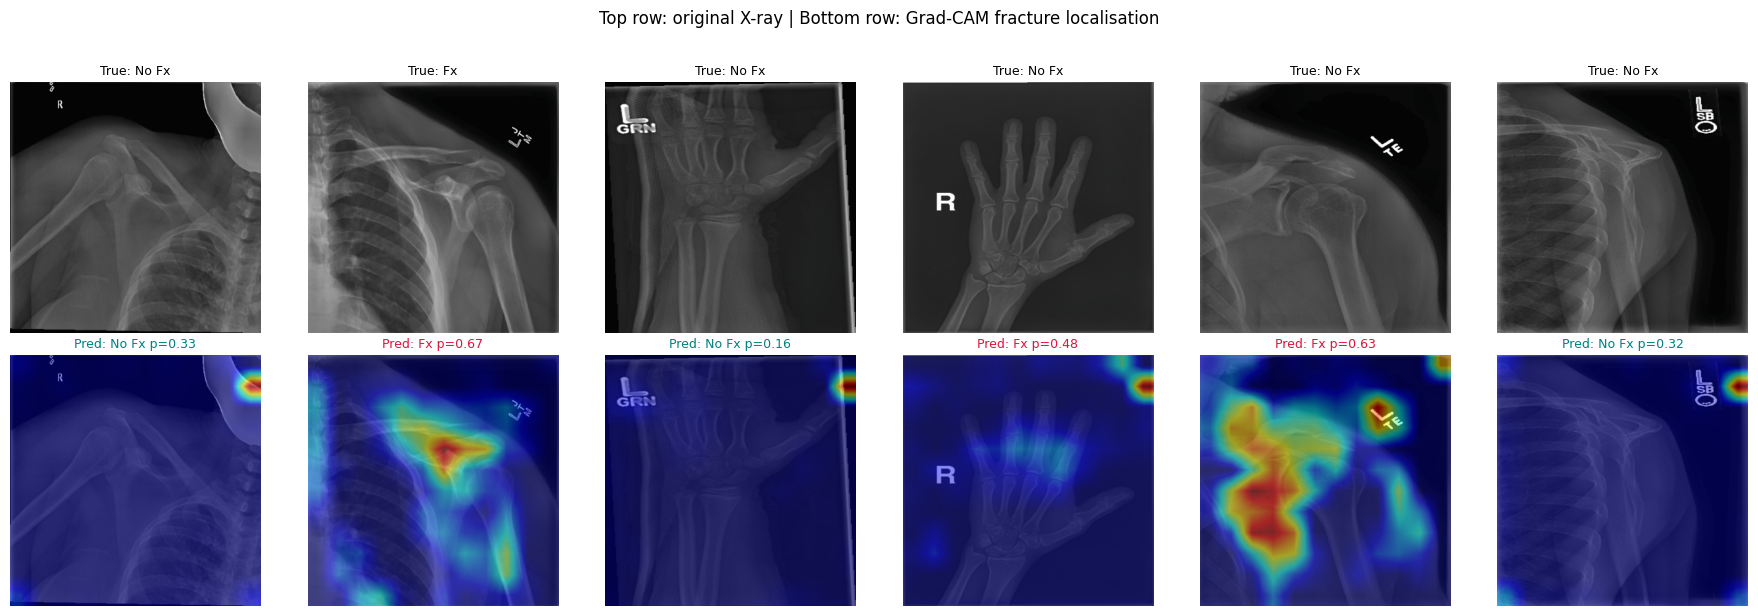

In [16]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# Target the last conv block of EfficientNet-B4
target_layer = [model.backbone.blocks[-1][-1]]

cam = GradCAM(
    model=model,
    target_layers=target_layer
)
# Fetch a batch of test images
imgs_batch, labels_batch = next(iter(test_loader))
imgs_batch = imgs_batch.to(CFG['device'])

with torch.no_grad():
    logits = model(imgs_batch).squeeze(1)
    probs  = torch.sigmoid(logits).cpu().numpy()

# Visualise first 6 images with Grad-CAM overlay
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
n    = min(6, len(imgs_batch))

fig, axes = plt.subplots(2, n, figsize=(3*n, 6))
for i in range(n):
    # Raw image
    raw = imgs_batch[i:i+1]
    img_np = raw[0].permute(1,2,0).cpu().numpy() * std + mean
    img_np = np.clip(img_np, 0, 1).astype(np.float32)

    # Grad-CAM heatmap
    grayscale_cam = cam(input_tensor=raw, targets=None)
    cam_img = show_cam_on_image(img_np, grayscale_cam[0], use_rgb=True)

    true  = int(labels_batch[i].item())
    pred  = 1 if probs[i] >= 0.4 else 0
    color = 'crimson' if pred else 'teal'

    axes[0, i].imshow(img_np); axes[0, i].axis('off')
    axes[0, i].set_title(f'True: {["No Fx","Fx"][true]}', fontsize=9)
    axes[1, i].imshow(cam_img); axes[1, i].axis('off')
    axes[1, i].set_title(f'Pred: {["No Fx","Fx"][pred]} p={probs[i]:.2f}',
                         fontsize=9, color=color)

plt.suptitle('Top row: original X-ray | Bottom row: Grad-CAM fracture localisation', y=1.02)
plt.tight_layout(); plt.show()

## 13. MC-Dropout uncertainty quantification

Run 30 stochastic forward passes per image with dropout ON. High variance = model is uncertain → route to radiologist queue rather than auto-report.

Batch size: 16
Escalated to radiologist queue (uncertainty ≥ 0.15): 0 images
Escalation rate: 0.0%


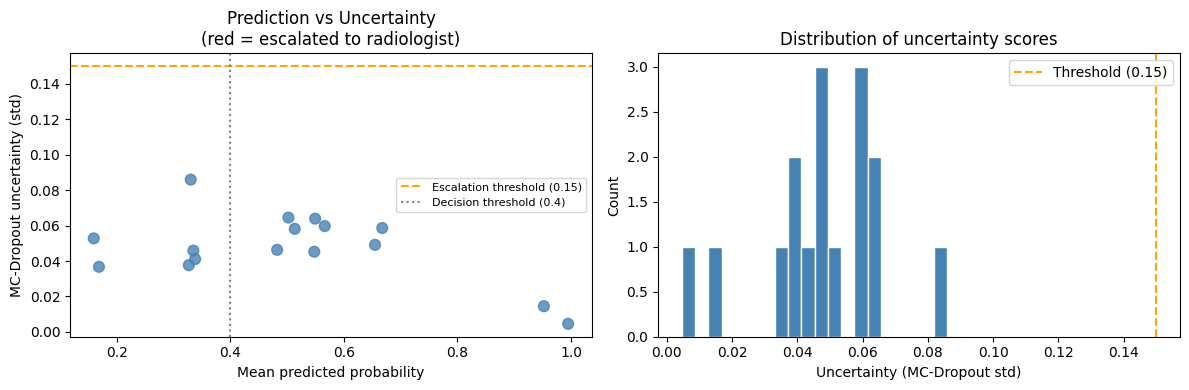

In [17]:
def mc_dropout_predict(model, imgs: torch.Tensor,
                       n_samples: int = 30) -> dict:
    """
    Returns per-image:
      - mean_prob: mean predicted fracture probability across N passes
      - uncertainty: std of predicted probabilities (epistemic uncertainty)
    """
    model.eval()
    model.enable_dropout()  # keep dropout ON
    all_probs = []
    with torch.no_grad():
        for _ in range(n_samples):
            logits = model(imgs).squeeze(1)
            all_probs.append(torch.sigmoid(logits).cpu().numpy())
    all_probs = np.stack(all_probs, axis=0)  # (n_samples, batch)
    mean_prob   = all_probs.mean(axis=0)
    uncertainty = all_probs.std(axis=0)
    return {'mean_prob': mean_prob, 'uncertainty': uncertainty}


# Run on a test batch
imgs_batch, labels_batch = next(iter(test_loader))
imgs_batch = imgs_batch.to(CFG['device'])

mc_out = mc_dropout_predict(model, imgs_batch, n_samples=CFG['mc_samples'])
mean_p = mc_out['mean_prob']
unc    = mc_out['uncertainty']

# Flag images for radiologist review
thr = CFG['uncertainty_thr']
escalate = unc >= thr

print(f'Batch size: {len(imgs_batch)}')
print(f'Escalated to radiologist queue (uncertainty ≥ {thr}): {escalate.sum()} images')
print(f'Escalation rate: {escalate.mean():.1%}')

# Visualise uncertainty scores
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

scatter_color = ['crimson' if e else 'steelblue' for e in escalate]
ax1.scatter(mean_p, unc, c=scatter_color, s=60, alpha=0.8)
ax1.axhline(thr, color='orange', linestyle='--', label=f'Escalation threshold ({thr})')
ax1.axvline(0.4, color='gray',   linestyle=':',  label='Decision threshold (0.4)')
ax1.set_xlabel('Mean predicted probability'); ax1.set_ylabel('MC-Dropout uncertainty (std)')
ax1.set_title('Prediction vs Uncertainty\n(red = escalated to radiologist)')
ax1.legend(fontsize=8)

ax2.hist(unc, bins=20, color='steelblue', edgecolor='white')
ax2.axvline(thr, color='orange', linestyle='--', label=f'Threshold ({thr})')
ax2.set_xlabel('Uncertainty (MC-Dropout std)'); ax2.set_ylabel('Count')
ax2.set_title('Distribution of uncertainty scores')
ax2.legend()

plt.tight_layout(); plt.show()

## 14. Image quality gate

Reject blurry or underexposed images before they reach the fracture detector. This prevents the model running on artefact-heavy portable-unit images that would produce unreliable predictions.

In [18]:
def image_quality_score(img_bgr: np.ndarray) -> dict:
    """
    Returns quality signals:
      - blur_score: Laplacian variance (higher = sharper). Reject if < 80
      - exposure_ok: True if mean pixel in [30, 220] (not over/underexposed)
      - snr_db: rough signal-to-noise ratio estimate
    """
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blur_score  = cv2.Laplacian(gray, cv2.CV_64F).var()
    mean_px     = gray.mean()
    exposure_ok = 30 < mean_px < 220
    # SNR: mean / std of pixel values
    snr_db      = 20 * np.log10(mean_px / (gray.std() + 1e-6))
    return {
        'blur_score':  round(blur_score, 2),
        'exposure_ok': exposure_ok,
        'snr_db':      round(snr_db, 2),
        'pass_gate':   blur_score >= 80 and exposure_ok
    }


def should_request_retake(img_path: str) -> bool:
    img = cv2.imread(img_path)
    if img is None:
        return True  # unreadable = reject
    quality = image_quality_score(img)
    if not quality['pass_gate']:
        print(f'Rejected: {quality}')
        return True
    return False


# Run quality check on a sample of test images
sample_paths = test_df['path'].sample(min(20, len(test_df)), random_state=0).values
quality_results = []
for p in sample_paths:
    img = cv2.imread(p)
    if img is not None:
        q = image_quality_score(img)
        quality_results.append(q)

qdf = pd.DataFrame(quality_results)
print(f'Quality gate pass rate: {qdf["pass_gate"].mean():.1%}')
print(f'Blur score stats:\n{qdf["blur_score"].describe().round(1)}')
print(qdf.head(10))

Quality gate pass rate: 85.0%
Blur score stats:
count     20.0
mean     299.0
std      223.8
min       30.3
25%      123.0
50%      227.3
75%      406.4
max      927.3
Name: blur_score, dtype: float64
   blur_score  exposure_ok  snr_db  pass_gate
0      333.64         True    1.21       True
1      122.48        False   -2.59      False
2      254.63         True   -0.48       True
3      386.01         True    4.04       True
4      200.01         True   -1.98       True
5       80.97         True   -1.84       True
6      174.11         True   -0.01       True
7      102.10         True   -2.63       True
8      460.98         True    7.39       True
9      396.61         True    3.79       True


## 15. Complete inference function

Single function that runs the full pipeline: quality gate → CLAHE → EfficientNet-B4 → MC-Dropout uncertainty → decision.

In [21]:
INFER_TRANSFORM = get_transforms('val', CFG['img_size'])

def predict_single(img_path: str, model: nn.Module,
                   threshold: float = 0.4) -> dict:
    """
    Full inference pipeline for one X-ray image.
    Returns:
      status: 'retake' | 'radiologist_queue' | 'no_fracture' | 'fracture'
      fracture_prob: mean fracture probability (0-1)
      uncertainty: MC-Dropout std
      action: recommended clinical action
    """
    # 1. Quality gate
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        return {'status': 'retake', 'action': 'Image unreadable — retake required'}
    quality = image_quality_score(img_bgr)
    if not quality['pass_gate']:
        return {'status': 'retake',
                'action': f'Image quality too low (blur={quality["blur_score"]}) — retake required',
                'quality': quality}

    # 2. Preprocess
    img_clahe = apply_clahe(img_bgr)
    img_rgb   = cv2.cvtColor(img_clahe, cv2.COLOR_BGR2RGB)
    tensor    = INFER_TRANSFORM(image=img_rgb)['image'].unsqueeze(0).to(CFG['device'])

    # 3. MC-Dropout inference
    mc_out = mc_dropout_predict(model, tensor, n_samples=CFG['mc_samples'])
    prob   = float(mc_out['mean_prob'][0])
    unc    = float(mc_out['uncertainty'][0])

    # 4. Route decision
    if unc >= CFG['uncertainty_thr']:
        status = 'radiologist_queue'
        action = f'Borderline case (uncertainty={unc:.3f}) — radiologist review required'
    elif prob >= threshold:
        status = 'fracture'
        action = 'Fracture detected — urgent referral to orthopaedic'
    else:
        status = 'no_fracture'
        action = 'No fracture detected — Grade 1 sprain likely, RICE protocol advised'

    return {
        'status':        status,
        'fracture_prob': round(prob, 4),
        'uncertainty':   round(unc, 4),
        'action':        action,
        'quality':       quality,
    }


# Demo on one test image
sample_img = test_df.sample(1).iloc[0]
result = predict_single(sample_img['path'], model)
print('=== Inference result ===')
for k, v in result.items():
    print(f'  {k}: {v}')
print(f'\nGround truth label: {["No fracture", "Fracture"][sample_img["label"]]}')

=== Inference result ===
  status: fracture
  fracture_prob: 0.9993
  uncertainty: 0.0005
  action: Fracture detected — urgent referral to orthopaedic
  quality: {'blur_score': np.float64(297.08), 'exposure_ok': np.True_, 'snr_db': np.float64(5.01), 'pass_gate': np.True_}

Ground truth label: Fracture


## 16. Export for deployment

Export to ONNX for lightweight inference on edge devices (Android / Raspberry Pi at rural health centres).

In [24]:
!pip install onnx onnxscript
ONNX_PATH = CKPT_PATH.replace('.pt', '.onnx')

model.eval()
dummy_input = torch.randn(1, 3, CFG['img_size'], CFG['img_size']).to(CFG['device'])

torch.onnx.export(
    model,
    dummy_input,
    ONNX_PATH,
    export_params=True,
    opset_version=17,
    input_names=['xray_image'],
    output_names=['fracture_logit'],
    dynamic_axes={
        'xray_image':    {0: 'batch_size'},
        'fracture_logit':{0: 'batch_size'}
    },
    verbose=False
)
print(f'ONNX model saved to {ONNX_PATH}')

# Optional: verify with onnxruntime
try:
    import onnxruntime as ort
    sess = ort.InferenceSession(ONNX_PATH, providers=['CPUExecutionProvider'])
    ort_out = sess.run(None, {'xray_image': dummy_input.cpu().numpy()})
    print(f'ONNX inference verified. Output shape: {ort_out[0].shape}')
except ImportError:
    print('onnxruntime not installed — skipping verification (pip install onnxruntime)')

/tmp/ipykernel_57/1988014354.py:7: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0523 12:27:06.351000 57 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0523 12:27:06.848000 57 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, al

ONNX model saved to /kaggle/working/best_fracture_model.onnx
ONNX inference verified. Output shape: (1, 1)


---
## Next steps

| Step | Action |
|---|---|
| Sensitivity < 95% | Lower decision threshold from 0.4 → 0.35, or increase `pos_weight` from 2.5 → 3.5 |
| High uncertainty rate | Collect more borderline cases; tune `uncertainty_thr` on validation set |
| Add NLP triage | Fine-tune MuRIL (multilingual BERT) on symptom text; integrate before X-ray flow |
| Hospital data | Add real portable-unit X-rays; retrain with CLAHE augmentation on that distribution |
| CDSCO prep | Version each checkpoint; attach sensitivity/specificity logs for regulatory dossier |
| Production | Quantise ONNX model with INT8 for on-device inference on Android |
